# 00 | Sanity Check for Data Pipeline

> This notebook runs a minimal end-to-end check to verify that the `Food-101` dataset, image transforms, and `DataLoader` pipeline are working as expected.

**What we verify**
- Import the required libraries
- Detect the active compute device
- Define a basic image transform
- Load the `Food-101` training split
- Visualize one sample and fetch one batch

## 1. Import

In [ ]:
import torch
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## 2. Check the Device

Prefer `MPS` when available; otherwise fall back to `CPU`.

In [2]:
# Use Apple Metal when available, otherwise default to CPU
if torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Using device:", device)

Using device: mps


## 3. Define the Transform

Apply only the minimal preprocessing needed for a quick pipeline check.

In [ ]:
# Minimal preprocessing for a quick sanity check
transform = transforms.Compose([
    # Resize all images to a fixed input size
    transforms.Resize((224, 224)),
    # Convert PIL images to PyTorch tensors
    transforms.ToTensor(),
    # The normalization step is not necessary for this sanity check
])

## 4. Load Food-101

Download and initialize the training set, then confirm the dataset size and number of classes.

In [4]:
# Load the Food-101 training split
train_dataset = datasets.Food101(
    root="./data",
    split="train",
    transform=transform,
    download=True
)

# Quick dataset-level checks
print("Train dataset size:", len(train_dataset))
print("Number of classes:", len(train_dataset.classes))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5.00G/5.00G [09:15<00:00, 9.00MB/s]


Train dataset size: 75750
Number of classes: 101


## 5. Inspect One Sample

Check that the image shape, label index, and class name all line up correctly.

Image shape: torch.Size([3, 224, 224])
Label: 23
Class name: churros


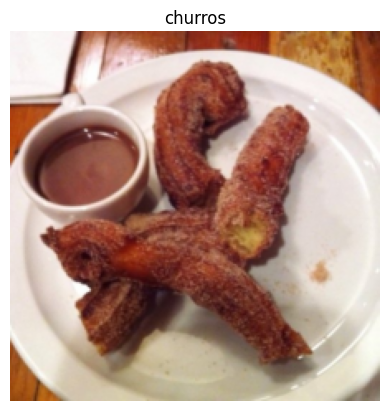

In [ ]:
# Read one sample from the dataset
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class name:", train_dataset.classes[label])

# Convert [C, H, W] tensor to [H, W, C] format for matplotlib
plt.imshow(image.permute(1, 2, 0))
plt.title(train_dataset.classes[label])
plt.axis("off")
plt.show()

## 6. Build the DataLoader

Create a small shuffled loader to prepare for later training experiments.

In [ ]:
# Wrap the dataset into mini-batches for iteration
train_loader = DataLoader(
    train_dataset,
    batch_size=8, # The batch size does not matter for this sanity check
    shuffle=True
)

## 7. Fetch One Batch

Run one final shape and dtype check to confirm the input pipeline is ready.

In [ ]:
# Pull one batch to verify the loader output format
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Images dtype:", images.dtype)
print("Labels dtype:", labels.dtype)
print("Label min:", labels.min().item())
print("Label max:", labels.max().item())

Images shape: torch.Size([8, 3, 224, 224])
Labels shape: torch.Size([8])
Images dtype: torch.float32
Labels dtype: torch.int64
Label min: 0
Label max: 61
